# Порождение временных признаков в задаче регрессии

Возьмем готовую коллекцию данных [про остров тепла Москвы (DUHI)]([https://github.com/mvarentsov/ML4hydromet-2025/tree/main/datasets/DUHI])


In [1]:
import pandas as pd 
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.model_selection import ShuffleSplit, KFold

from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor

plt.rcParams['figure.dpi'] = 150

### Читаем данные, удаляем лишнее

In [11]:

df = pd.read_csv ("../datasets/DUHI/Moscow_basic.csv", sep=';', parse_dates=['time'], index_col=['time'])
df = df.drop(columns = [c for c in df.columns if ('delta' in c and c != 'delta_t2m_id27605') or 'rur' in c] + ['ERA5_ps'])

display(df.head())
display(df.describe().T)



C:\Users\mvar9\AppData\Local\Temp\ipykernel_10444\1773318099.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv ("../datasets/DUHI/Moscow_basic.csv", sep=';', parse_dates=['time'], index_col=['time'])


,delta_t2m_id27605,ERA5_t2m,ERA5_u10m,ERA5_v10m,ERA5_tcc,ERA5_lcc,ERA5_blh,ERA5_str,ERA5_ssr,ERA5_ssrd,ERA5_strd,ERA5_vel10m,ERA5_dir10,ERA5_tp_3h,ERA5_rh2m
time,,,,,,,,,,,,,,,
2012-01-01 00:00:00,1.13,-1.30,-2.03,0.49,1.00,0.97,196.13,-7.85,0.00,0.00,301.78,2.09,103.55,0.27,97.01
2012-01-01 03:00:00,0.63,-1.38,-1.42,-0.18,1.00,1.00,165.84,-5.97,0.00,0.00,302.89,1.43,82.61,1.04,97.35
2012-01-01 06:00:00,0.93,-1.77,0.75,0.61,1.00,0.93,112.22,-12.21,0.00,0.00,293.34,0.96,230.87,0.62,97.97
2012-01-01 09:00:00,0.87,-1.71,2.42,1.56,0.94,0.88,307.48,-32.96,41.58,85.21,275.55,2.88,237.26,0.39,96.23
2012-01-01 12:00:00,0.69,-1.29,0.92,0.96,0.71,0.67,231.04,-19.30,24.45,49.29,290.98,1.32,223.83,0.09,93.68


,count,mean,std,min,25%,50%,75%,max
delta_t2m_id27605,34071.0,2.002391,1.707798,-6.29,0.9200,1.480,2.600,11.47
ERA5_t2m,34088.0,5.963003,10.755316,-34.70,-1.4800,5.600,14.460,32.94
ERA5_u10m,34088.0,0.718380,2.582795,-7.77,-1.1700,0.820,2.540,11.55
ERA5_v10m,34088.0,0.378190,2.731026,-9.91,-1.6400,0.490,2.380,9.52
ERA5_tcc,34088.0,0.707743,0.355778,0.00,0.4400,0.910,1.000,1.00
ERA5_lcc,34088.0,0.452457,0.420196,0.00,0.0100,0.340,0.940,1.00
ERA5_blh,34088.0,589.920067,489.975471,11.24,226.4075,463.380,801.395,3293.05
ERA5_str,34085.0,-46.655100,31.188789,-150.69,-69.5100,-44.640,-18.710,14.18
ERA5_ssr,34085.0,98.054006,160.686015,0.00,0.0000,4.750,130.300,711.73
ERA5_ssrd,34085.0,119.940783,189.469910,0.00,0.0000,6.410,172.380,830.45


### Немного EDA

<Axes: >

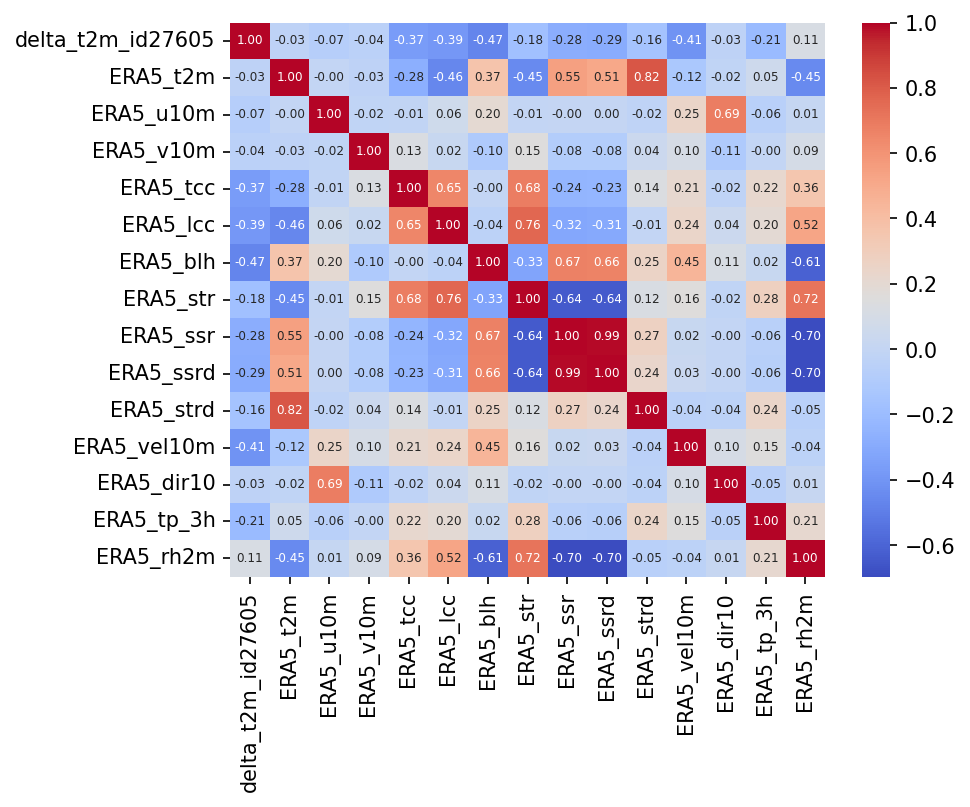

In [3]:
sns.heatmap (df.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={'size': 'xx-small'})

### Порождаем временные признаки (тенденции, бегущие средние)

In [12]:
def tendency (X, axis=0):
    """
    Calculate the tendency (change) of a numpy array along a specified axis.
    
    Computes the difference between the last and first elements of an array along the given axis.
    
    Args:
        X (array-like): Input array to calculate tendency from.
        axis (int, optional): Axis along which to calculate tendency. Defaults to 0.
    
    Returns:
        numpy.ndarray: Array representing the tendency (change) between the last and first elements.
    """
    if not isinstance (X, np.ndarray):
        X = np.asarray(X)
    indices_first = [0 if dim == axis else slice (0, X.shape[dim]) for dim in range(X.ndim)]
    indices_last  = [X.shape[dim]-1 if dim == axis else slice (0, X.shape[dim]) for dim in range(X.ndim)]
    return X[*indices_last]- X[*indices_first]



vars4TFs = ['ERA5_t2m']
TF_windows = [1, 2, 4, 8]

for var_td in vars4TFs:
    for TF_window in TF_windows:
        #df[f'{var_td}_TFshifted_{TF_window*3}h'] = df[var_td].shift(-TF_window)
        df[f'{var_td}_TFma_{TF_window*3}h'] = df[var_td].rolling(TF_window+1).mean()
        df[f'{var_td}_TFtd_{TF_window*3}h'] = df[var_td].rolling(TF_window+1).apply(tendency)

df[[c for c in df.columns if 't2m' in c]]


,delta_t2m_id27605,ERA5_t2m,ERA5_t2m_TFma_3h,ERA5_t2m_TFtd_3h,ERA5_t2m_TFma_6h,ERA5_t2m_TFtd_6h,ERA5_t2m_TFma_12h,ERA5_t2m_TFtd_12h,ERA5_t2m_TFma_24h,ERA5_t2m_TFtd_24h
time,,,,,,,,,,
2012-01-01 00:00:00,1.13,-1.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-01 03:00:00,0.63,-1.38,-1.340,-0.08,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-01 06:00:00,0.93,-1.77,-1.575,-0.39,-1.483333,-0.47,NaN,NaN,NaN,NaN
2012-01-01 09:00:00,0.87,-1.71,-1.740,0.06,-1.620000,-0.33,NaN,NaN,NaN,NaN
2012-01-01 12:00:00,0.69,-1.29,-1.500,0.42,-1.590000,0.48,-1.490,0.01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2023-08-31 09:00:00,0.81,22.30,19.835,4.93,17.056667,10.80,15.078,9.93,15.974444,5.10
2023-08-31 12:00:00,0.20,24.78,23.540,2.48,21.483333,7.41,17.560,12.93,16.816667,5.71
2023-08-31 15:00:00,0.64,23.66,24.220,-1.12,23.580000,1.36,19.922,12.16,17.326667,5.18


<Axes: >

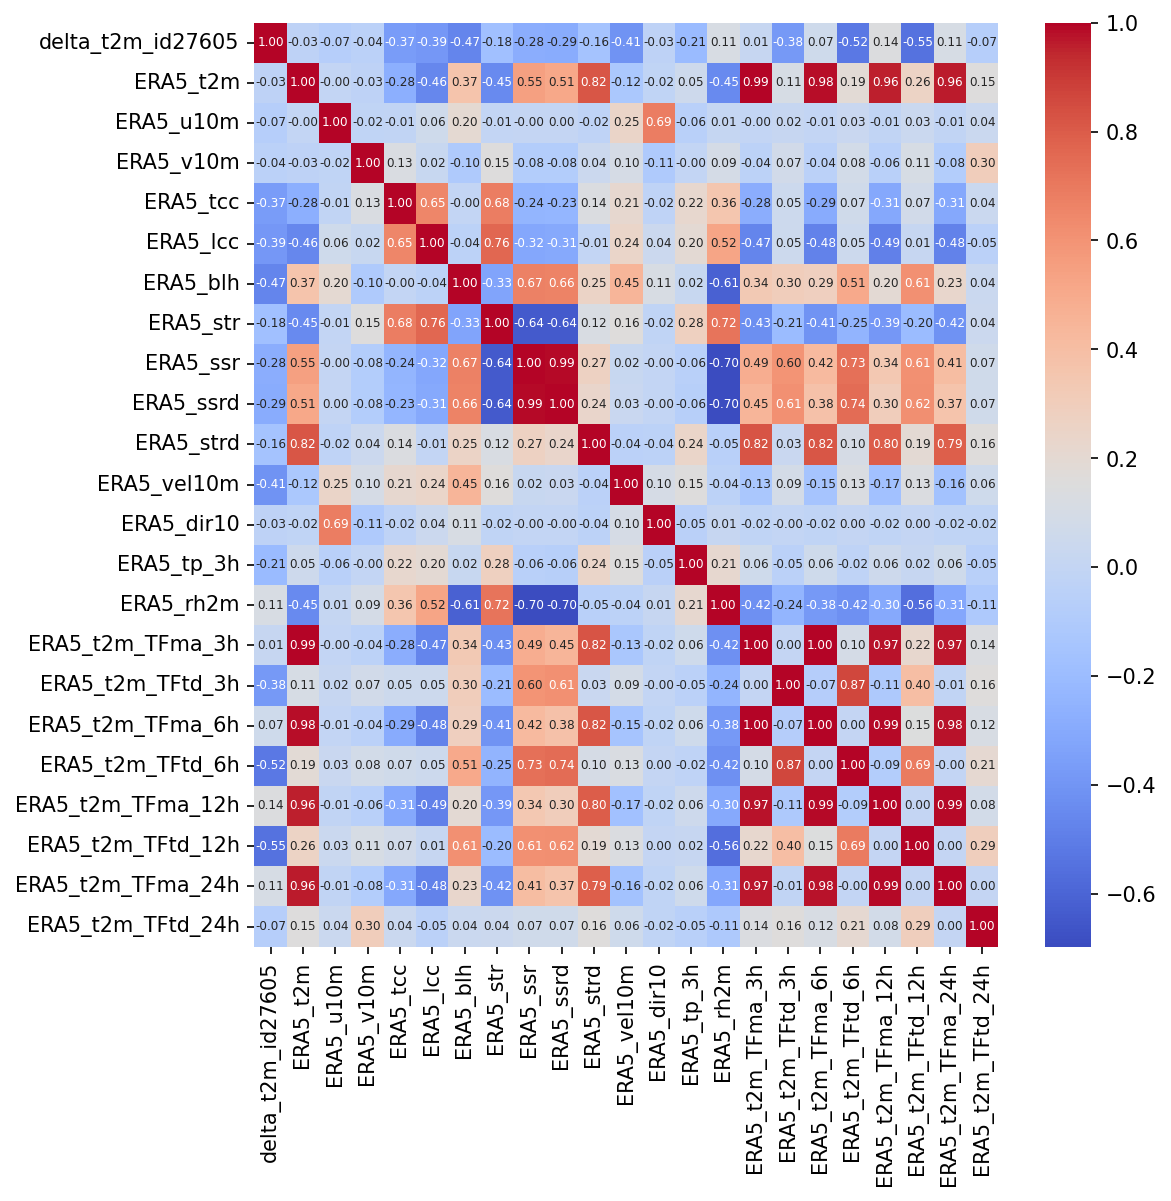

In [13]:
plt.figure(figsize=(8,8))
sns.heatmap (df.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={'size': 'xx-small'})

In [14]:
target = 'delta_t2m_id27605'
df4ml = df.dropna() #.sample(2000)
X = df4ml.drop (columns=[target])
Y = df4ml[target]

models = [LinearRegression (), CatBoostRegressor (silent=True)] 

cv = ShuffleSplit (n_splits=5, random_state = 42)

normalization = True

cv_results = {}

for use_TFs in [False, True]:
    for model in tqdm(models):

        if not use_TFs:
            X4ML = X [[c for c in X.columns if 'TF' not in c]]
        else:
            X4ML = X

        model_pp = Pipeline([
                            ('scaler', StandardScaler(with_mean=normalization, with_std=normalization)),
                            ('regressor', model)
                            ])

        cur_cv_results = cross_validate(model_pp, X4ML, Y, cv=cv, n_jobs=8,
                                    scoring=['r2', 'neg_root_mean_squared_error'],
                                    return_train_score = True, return_estimator=True, return_indices=True)

        cur_cv_results['train_idx'] = cur_cv_results['indices']['train']
        cur_cv_results['test_idx'] = cur_cv_results['indices']['test']
        cur_cv_results.pop('indices')

        
        cur_cv_results['model'] = model.__class__.__name__
        cur_cv_results['model_full'] = model.__class__.__name__ + ('+TFs' if use_TFs else '')
        cur_cv_results['TFs'] = use_TFs

        cur_cv_results = pd.DataFrame(cur_cv_results)

        cur_cv_results['feature_names'] = list([X4ML.columns])*cur_cv_results.shape[0]
        
        
        cv_results[model.__class__.__name__ + ('_TF' if use_TFs else '')] = cur_cv_results


print ('finished')
sys.exit()

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:30<00:00, 15.11s/it]

finished


NameError: name 'sys' is not defined

### Собираем результаты кросс-валидации в DataFrame

In [15]:
cv_results_df = pd.concat ([pd.DataFrame(cv_results[model]) for model in cv_results.keys()], ignore_index=True)

cv_results_df['test_rmse'] = -cv_results_df['test_neg_root_mean_squared_error']
cv_results_df['train_rmse'] = -cv_results_df['train_neg_root_mean_squared_error']

cv_results_df.head()



,fit_time,score_time,estimator,test_r2,train_r2,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,train_idx,test_idx,model,model_full,TFs,feature_names,test_rmse,train_rmse
0,0.094035,0.010135,"(StandardScaler(), LinearRegression())",0.503158,0.507033,-1.196497,-1.200000,"[8213, 25137, 11309, 18303, 21992, 1758, 27945...","[4990, 26461, 23294, 28813, 21798, 21864, 2706...",LinearRegression,LinearRegression,False,"Index(['ERA5_t2m', 'ERA5_u10m', 'ERA5_v10m', '...",1.196497,1.200000
1,0.095765,0.008404,"(StandardScaler(), LinearRegression())",0.526750,0.504197,-1.195644,-1.200133,"[23968, 24686, 12550, 16810, 16204, 20295, 280...","[23350, 16349, 13404, 16745, 17825, 20304, 997...",LinearRegression,LinearRegression,False,"Index(['ERA5_t2m', 'ERA5_u10m', 'ERA5_v10m', '...",1.195644,1.200133
2,0.097822,0.009405,"(StandardScaler(), LinearRegression())",0.499868,0.507390,-1.212469,-1.198220,"[27835, 1677, 32215, 23627, 26388, 3943, 11554...","[26182, 7862, 25603, 4287, 10822, 22332, 20673...",LinearRegression,LinearRegression,False,"Index(['ERA5_t2m', 'ERA5_u10m', 'ERA5_v10m', '...",1.212469,1.198220
3,0.096808,0.008404,"(StandardScaler(), LinearRegression())",0.510985,0.506148,-1.190371,-1.200701,"[18851, 28990, 30170, 24207, 17807, 3949, 3152...","[203, 18776, 25132, 6095, 7487, 19600, 13725, ...",LinearRegression,LinearRegression,False,"Index(['ERA5_t2m', 'ERA5_u10m', 'ERA5_v10m', '...",1.190371,1.200701
4,0.097822,0.010432,"(StandardScaler(), LinearRegression())",0.502150,0.507097,-1.207351,-1.198805,"[11292, 25898, 7160, 599, 502, 23075, 11096, 3...","[15358, 4560, 11226, 20234, 8087, 18034, 2836,...",LinearRegression,LinearRegression,False,"Index(['ERA5_t2m', 'ERA5_u10m', 'ERA5_v10m', '...",1.207351,1.198805


## Строим диаграммы рассеяния для разных моделей и выборок (train/test) по всем итерациям кросс-валидации

In [16]:
reg_results = []

for i in cv_results_df.index:
    train_idx = cv_results_df.loc[i, 'train_idx']
    test_idx =  cv_results_df.loc[i, 'test_idx']
    
    cur_Y_train = Y.iloc[train_idx]
    cur_Y_test  = Y.iloc[test_idx]

    if not cv_results_df.loc[i, 'TFs']:
        X4ML = X [[c for c in X.columns if 'TF' not in c]]
    else:
        X4ML = X

    cur_X_train = X4ML.iloc[train_idx]
    cur_X_test  = X4ML.iloc[test_idx]

    cur_Y_train_pred = cv_results_df.loc[i, 'estimator'].predict(cur_X_train)
    cur_Y_test_pred  = cv_results_df.loc[i, 'estimator'].predict(cur_X_test)
    
    #reg_results.append (pd.DataFrame({'Y':cur_Y_train, 'Y_pred':cur_Y_train_pred, 'model': cv_results_df.loc[i,'model'], 'type': 'train'}))
    reg_results.append (pd.DataFrame({'Y':cur_Y_test,  'Y_pred':cur_Y_test_pred,  'model': cv_results_df.loc[i,'model'], 'type': 'test', 'TFs':cv_results_df.loc[i, 'TFs']}))
    
reg_results = pd.concat(reg_results)

<Figure size 960x720 with 0 Axes>

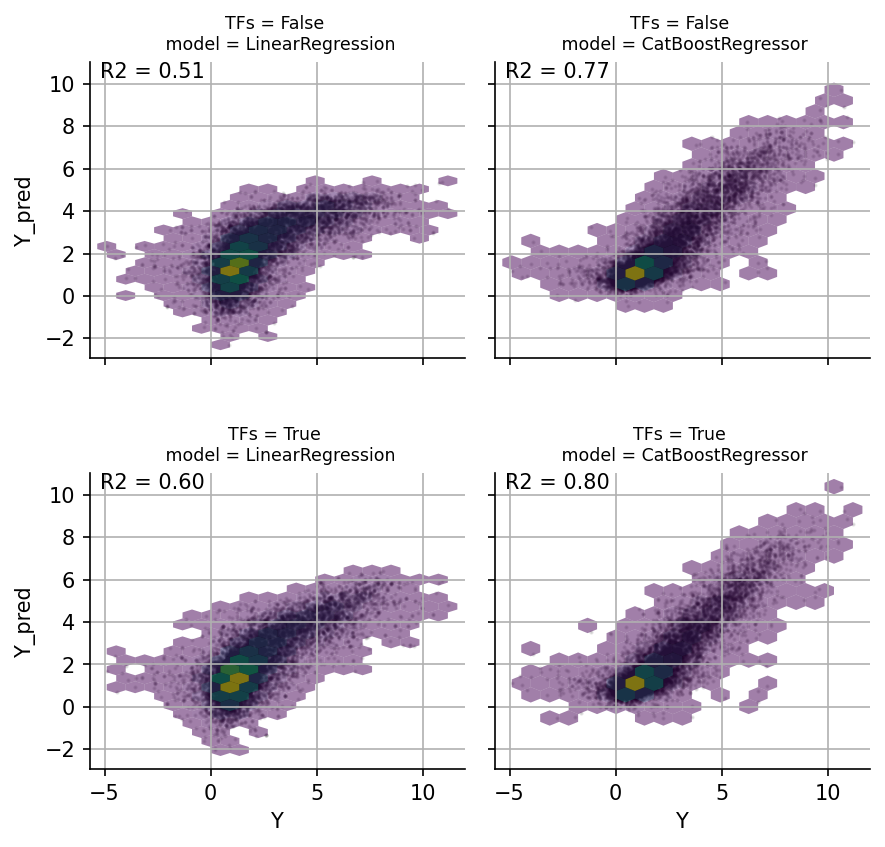

In [17]:
from sklearn.metrics import r2_score

def myhexbin(*args, **kwargs):
        kwargs.pop("color", None)
        hb = plt.hexbin(*args, **kwargs)
        Y = args[0]
        Y_pred = args[1]
        r2 = r2_score (Y, Y_pred) 
        x_lim = plt.xlim()
        y_lim = plt.ylim()
        plt.text(x_lim[0] + 0.5, y_lim[1], f'R2 = {r2:.2f}', ha = 'left', va='top')
        return hb

plt.figure()
g = sns.FacetGrid (reg_results, col = 'model', row='TFs')
g.map(plt.scatter, 'Y', 'Y_pred', s=1, color = 'black', alpha=0.1) 
g.map(myhexbin, 'Y', 'Y_pred', mincnt=1, gridsize=18, alpha = 0.5, edgecolor = None) 

for ax in g.axes.flatten():
        ax.set_title(ax.title.get_text().replace('|', '\n'), fontsize='small')
        ax.set_aspect('equal')
        ax.grid(zorder=0)



([0, 1, 2, 3],
 [Text(0, 0, 'LinearRegression'),
  Text(1, 0, 'CatBoostRegressor'),
  Text(2, 0, 'LinearRegression+TFs'),
  Text(3, 0, 'CatBoostRegressor+TFs')])

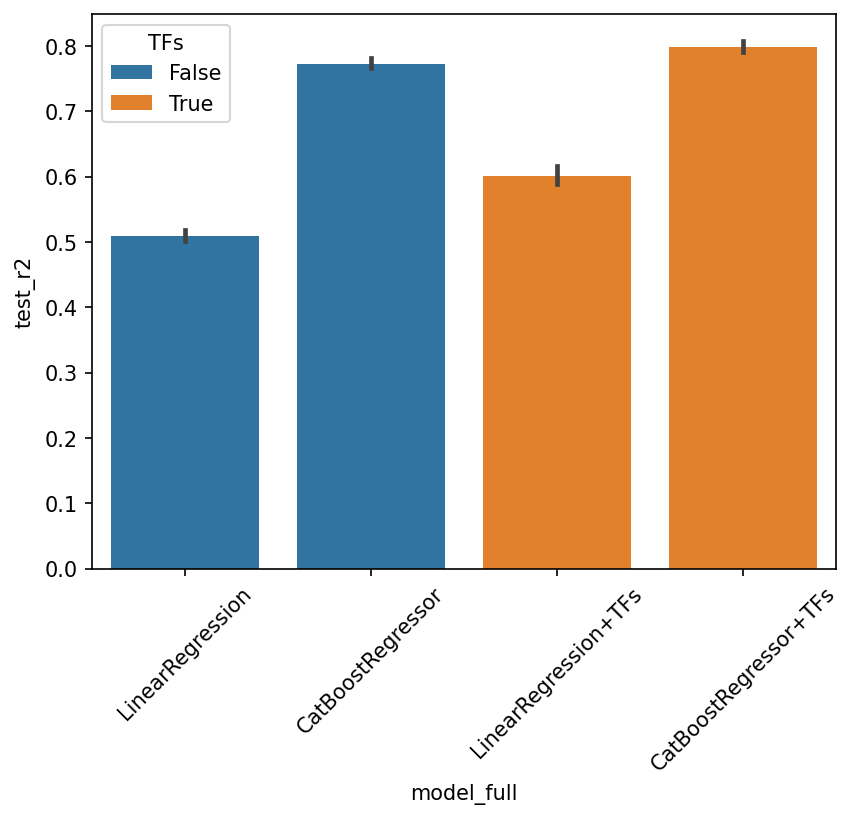

In [18]:
#cv_results_df['model_full_name'] = cv_results_df['model'] + '_TFs=' + cv_results_df['TFs'].astype(str)

plt.figure()
sns.barplot (cv_results_df, x='model_full', y='test_r2', hue = 'TFs')
plt.xticks(rotation=45)

### Сравним значимость признаков в подходе кросс-валидации

Пока кросс-валидация для быстроты самая примитивная, подразумеваем, что может заменить ее на Bootstap. 

In [ ]:
def extract_importance (cv_results_df, model_name,importance_attr):
    imp_df =  pd.concat([pd.DataFrame({'importance':getattr(model['estimator']['regressor'], importance_attr),
                                       'model': model_name,
                                       'feature': model['feature_names']}) for i, model in cv_results_df[cv_results_df['model_full'] == model_name].iterrows()])
    imp_df['importance'] = np.abs(imp_df['importance']) / np.sum(np.abs(imp_df['importance']))
    return imp_df

# imp_gbr = extract_importance(cv_results_df, 'GradientBoostingRegressor', 'feature_importances_')
# imp_rfr = extract_importance(cv_results_df, 'RandomForestRegressor', 'feature_importances_')
imp_lr_noTFs = extract_importance(cv_results_df[cv_results_df['TFs'] == False], 'LinearRegression', 'coef_')
imp_lr_TFs = extract_importance(cv_results_df[cv_results_df['TFs'] == True], 'LinearRegression+TFs', 'coef_')

<Figure size 900x1500 with 0 Axes>

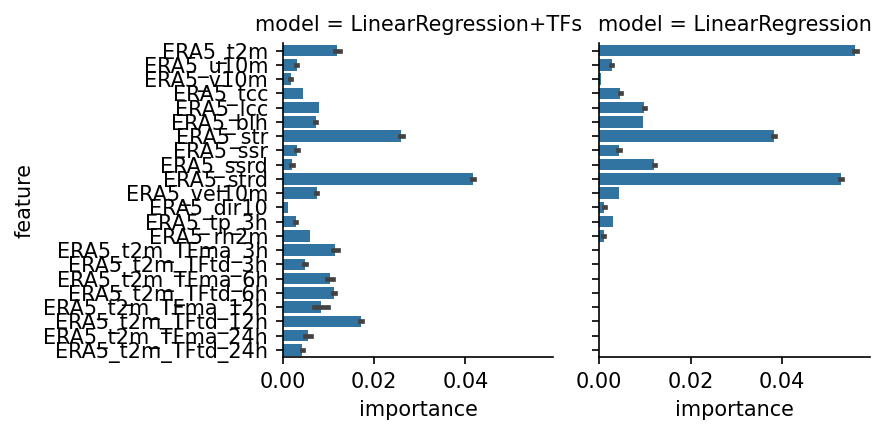

In [21]:
imp_all = pd.concat([imp_lr_TFs, imp_lr_noTFs], axis=0)

plt.figure(figsize=(6,10))
g = sns.FacetGrid (imp_all, col = 'model')
g.map (sns.barplot, 'importance', 'feature', order = X.columns)
